In [ ]:
#Lasso & Ridge regression

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd

from sklearn.model_selection import train_test_split

 

In [ ]:
df =  pd.read_csv("insurance.csv")

x = df.iloc[:,:-1]
y = df.iloc[:,-1]

# one hot encoding
x = pd.get_dummies(x,columns= ["region"] , drop_first = True ,dtype = int)1a

x["sex"] = x["sex"].map({"female" : 1, "male" : 0})
x["smoker"] = x["smoker"].map({"yes" : 1 , "no" :0})


# interactive feature

x["age_smoker"] =x["age"] * x["smoker"]
x["bmi_smoker"] = x["age"] * x["smoker"]


x_train , x_test , y_train ,y_test = train_test_split(
    x,y , test_size=  0.2 , random_state= 42)

In [19]:
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(x_train,y_train)


Lasso(alpha=0.5)

In [20]:
y_pred = lasso_model.predict(x_test)

In [21]:
mse = mean_squared_error(y_test,y_pred)
print(f"mse = {mse}")

mse = 33712400.779555716


mse for alpha = 0.001 : 33712400.779555716
mse for alpha = 0.1 : 33712400.779555716
mse for alpha = 1 : 33712400.779555716
mse for alpha = 2 : 33712400.779555716
mse for alpha = 3 : 33712400.779555716
mse for alpha = 5 : 33712400.779555716
mse for alpha = 6 : 33712400.779555716
mse for alpha = 7 : 33712400.779555716
mse for alpha = 8 : 33712400.779555716
mse for alpha = 89 : 33712400.779555716


<Axes: >

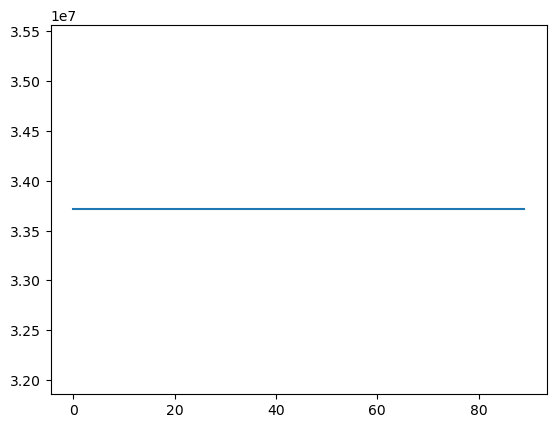

In [22]:
import seaborn as sns

alphas = [0.001,0.1,1,2,3,5,6,7,8,89]
mses = []
for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(x_train,y_train)
    print(f"mse for alpha = {a} :",mse)
    mses.append(mse)

sns.lineplot(x =alphas, y = mses)

In [23]:
from sklearn.linear_model import LassoCV
a = [0.001,0.1,1,2,3,10,20]

lasso_cv_model = LassoCV(
    alphas=a,
    cv =5,
    max_iter= 1000,
    random_state= 42
)

lasso_cv_model.fit(x_train,y_train)

print("best alpha: ",lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(x_test)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("mse = ",mse)
print("r2 = ",r2)

best alpha:  20.0
mse =  33981011.16207822
r2 =  0.7811189126277734
